# 02 - Trực quan dữ liệu sau khi làm sạch

Notebook này tập trung vào dữ liệu sau làm sạch và các đặc trưng phục vụ EDA.

Phạm vi dữ liệu:
- `review_id`
- `product_name`
- `content`
- các cột nhãn và feature sau làm sạch

Các biểu đồ gồm:
- số emoji theo sentiment
- biểu đồ tròn sentiment
- histogram số từ
- độ phủ khía cạnh và cấu trúc sentiment
- bảng xem trước dữ liệu
- dashboard n-gram
- word cloud
- chiếu 3D TF-IDF + t-SNE

## Ảnh xem trước trên GitHub

![Dataset snapshot](assets/eda_snapshot.png)

Ảnh tĩnh này giúp notebook hiển thị tốt trên GitHub. Chạy notebook cục bộ để tạo lại các biểu đồ Matplotlib bên dưới.


In [118]:
from pathlib import Path
import json
import math
import statistics
import seaborn as sns
from IPython import get_ipython
import emoji
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.manifold import TSNE
from IPython.display import display
from wordcloud import WordCloud

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "savefig.facecolor": "white",
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
        "legend.frameon": False,
    }
)

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 180)


In [119]:
def avg_word_len(text: str) -> float:
    words = text.split()
    if not words:
        return 0.0
    return float(np.mean([len(word) for word in words]))


def count_emojis(text: str) -> int:
    try:
        return len(emoji.emoji_list(text))
    except Exception:
        return 0


def normalize_text_for_ngrams(text: str) -> str:
    text = text.lower()
    text = " ".join(text.split())
    return text


def sentiment_subset(frame: pd.DataFrame, label: str) -> pd.DataFrame:
    return frame.loc[frame["sentiment_name"] == label].copy()


def top_ngrams(texts, ngram_range=(2, 2), top_n=15):
    vectorizer = CountVectorizer(
        ngram_range=ngram_range,
        token_pattern=r"(?u)\b[\w_]+\b",
        min_df=2,
    )
    matrix = vectorizer.fit_transform(texts)
    if matrix.shape[1] == 0:
        return pd.DataFrame(columns=["ngram", "count"])
    counts = np.asarray(matrix.sum(axis=0)).ravel()
    items = pd.DataFrame(
        {
            "ngram": vectorizer.get_feature_names_out(),
            "count": counts,
        }
    )
    return items.sort_values("count", ascending=False).head(top_n)


def style_axes(ax, grid_axis="y"):
    sns.despine(ax=ax)
    ax.set_axisbelow(True)
    ax.grid(axis=grid_axis, color="#dfe3eb", linewidth=0.8, alpha=0.9)


def annotate_vertical_bars(ax, bars, values, fmt="{:,.0f}", offset_ratio=0.015, fontsize=10):
    values = list(values)
    peak = max(values) if values else 0
    offset = peak * offset_ratio if peak else 0.01
    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + offset,
            fmt.format(value),
            ha="center",
            va="bottom",
            fontsize=fontsize,
        )


def annotate_horizontal_bars(ax, bars, values, fmt="{:,.0f}", offset_ratio=0.01, fontsize=10):
    values = list(values)
    peak = max(values) if values else 0
    offset = peak * offset_ratio if peak else 0.01
    for bar, value in zip(bars, values):
        ax.text(
            bar.get_width() + offset,
            bar.get_y() + bar.get_height() / 2,
            fmt.format(value),
            ha="left",
            va="center",
            fontsize=fontsize,
        )


In [120]:
# 1. Cấu hình đường dẫn nhanh (Tối giản find_project_root)
def get_root():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "data").exists(): return p
    return Path.cwd()
ROOT = get_root()
DATA_PATH = ROOT / "data/processed/train_clean.json"
SCAN_PATH = ROOT / "experiments/reports/train_clean_scan.json"
# 2. Định nghĩa cấu hình hiển thị (Gom nhóm các Constant)
SENTIMENT_COLORS = {"negative": "#d64b4b", "neutral": "#f0ad4e", "positive": "#2ca02c"}
SENTIMENT_DISPLAY = {"negative": "Tiêu cực", "neutral": "Trung lập", "positive": "Tích cực"}
SENTIMENT_ORDER = list(SENTIMENT_DISPLAY.keys())
SENTIMENT_MAP = {0: "negative", 1: "neutral", 2: "positive"}

def display_sentiment(label: str) -> str:
    return SENTIMENT_DISPLAY.get(label, str(label))

def display_aspect(aspect: str) -> str:
    return ASPECT_DISPLAY.get(aspect, aspect.replace("as_", "").capitalize())
ASPECT_DISPLAY = {
    "as_content": "Nội dung", "as_physical": "Chất lượng", "as_price": "Giá",
    "as_packaging": "Đóng gói", "as_delivery": "Giao hàng", "as_service": "Dịch vụ"
}
ASPECT_COLS = list(ASPECT_DISPLAY.keys())
# 3. Load và chuẩn hóa Data gọn nhẹ
df = pd.read_json(DATA_PATH)
# Tự động lấy ID và Product Column
ID_COL = "review_id" if "review_id" in df.columns else "product_id"
PRODUCT_COL = "product_name" if "product_name" in df.columns else ID_COL
# Fillna nhanh cho các cột text quan trọng
text_cols = ["product_name", "content_raw", "content"]
df[text_cols] = df[text_cols].fillna("").astype(str)
# 4. Trích xuất báo cáo chất lượng (Gọn hóa extract_metrics)
with open(SCAN_PATH, encoding="utf-8") as f:
    report = json.load(f)
def show_summary(report):
    c = report["checks"]
    metrics = {
        "Số dòng": report["metadata"]["row_count"],
        "Thiếu content": c["missing_values"]["per_column"]["content"]["missing_count"],
        "Dòng lỗi mã hóa": c["encoding"]["rows_with_any_issue"],
        "Dòng nhiễu": c["noise_patterns"]["rows_with_any_noise"],
        "Dòng có emoji": c["emoji"]["rows_with_emoji"],
        "Bản sao trùng": c["duplicates"]["normalized_duplicate_texts"]
    }
    display(pd.DataFrame([metrics], index=["Sau làm sạch"]).T)
# Thực thi hiển thị nhanh
print(f"Đã load {len(df):,} dòng dữ liệu sạch từ: {DATA_PATH.name}")
show_summary(report)

Đã load 10,696 dòng dữ liệu sạch từ: train_clean.json


,Sau làm sạch
Số dòng,10696
Thiếu content,0
Dòng lỗi mã hóa,23
Dòng nhiễu,649
Dòng có emoji,0
Bản sao trùng,0


In [121]:
df["sentiment_name"] = df["sentiment_llm"].map(SENTIMENT_MAP).fillna("unknown")
df["word_count"] = df["content"].apply(lambda x: len(x.split()))
df["char_count"] = df["content"].str.len()
df["avg_word_len"] = df["content"].apply(avg_word_len)
df["lexical_diversity"] = df["content"].apply(lambda x: len(set(x.split())) / (len(x.split()) + 1))
df["caps_ratio"] = df["content"].apply(lambda x: sum(1 for c in x if c.isupper()) / (len(x) + 1))
df["emoji_count"] = df["content_raw"].apply(count_emojis)
df["review_length_bucket"] = pd.cut(
    df["char_count"],
    bins=[0, 10, 20, 50, 100, 200, 500, 10_000],
    right=False,
)

display(
    df[
        [
            ID_COL,
            PRODUCT_COL,
            "sentiment_name",
            "content",
            "word_count",
            "char_count",
            "avg_word_len",
            "lexical_diversity",
            "caps_ratio",
            "emoji_count",
        ]
    ].head(5)
)

,review_id,product_name,sentiment_name,content,word_count,char_count,avg_word_len,lexical_diversity,caps_ratio,emoji_count
0,14357443,Sách Xứ Cát,neutral,"Sản phẩm thật sự chất lượng, và Tiki giao hàng nhanh như mọi khi. Tuy nhiên có đôi chỗ trong truyện dịch khá giống máy, tạo cảm giác kì cục",30,139,3.666667,0.967742,0.021429,0
1,16749123,Bộ sách Làm Giàu Từ Chứng Khoán (How To Make Money In Stock) phiên bản mới + Hướng Dẫn Thực Hành CANSLIM Cho Người Mới Bắt Đầu,negative,không phù hợp đầu tư dài hạn,7,28,3.142857,0.875000,0.000000,0
2,897166,Sách Predictably Irrational : The Hidden Forces That Shape Our Decisions (Revised and Updated Edition),negative,"Cuốn sách không đúng khổ ghi trên thông tin, khổ rất nhỏ như sổ tay và bìa chất lượng kém. yêu cầu tiki ghi đúng số liệu cuốn sách",29,130,3.517241,0.833333,0.007634,0
3,9105241,Siêu Cò – How To Be A Power Connector,neutral,"Sách hay, nội dung hấp dẫn, thiết thực. Chấm 5 sao. Giao hàng nhanh, tốt. Tuy nhiên phần book_care làm ẩu, dính bẩn lem nhem như hình.",27,134,4.000000,0.964286,0.029630,0
4,6820537,Sách Elon Musk: How The Billionaire CEO Of Spacex And Tesla Is Shaping Our Future,neutral,sách chất lượng in chưa được cao,7,32,3.714286,0.875000,0.000000,0


## Khám phá review ngẩu nhiên


--- THÔNG TIN CHI TIẼt REVIEW [Index: 3544] ---
Sản phẩm: Sách 301 Câu Đàm Thoại Tiếng Trung Quốc - Tập 1 (Kèm CD Hoặc File MP3) - Tái Bản (28 reviews)
Cảm xúc: Tích cực

NỘI DUNG ĐÃ LÀM SẠCH:
In rõ, gói cẩn thận


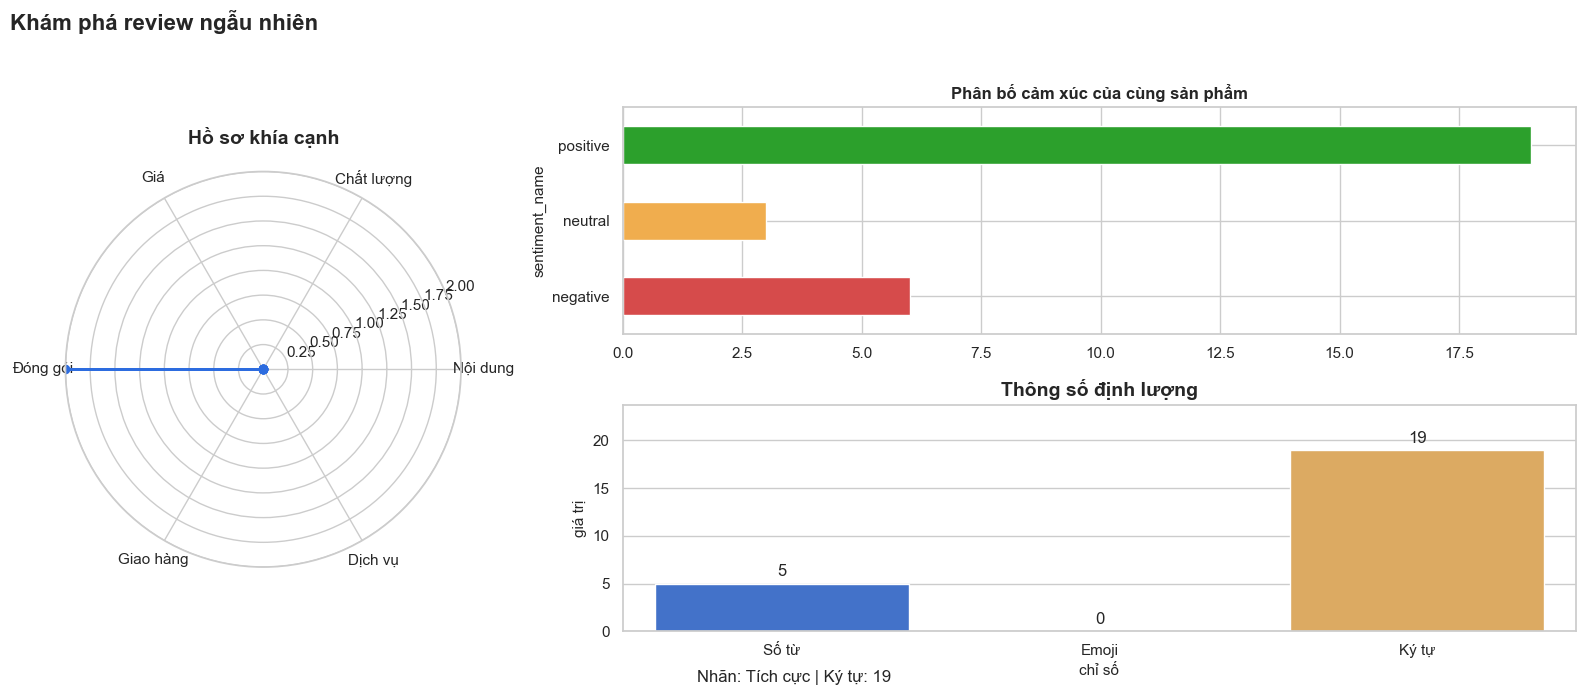

,Loại,Nội dung
0,NỘI DUNG ĐÃ LÀM SẠCH,"In rõ, gói cẩn thận"


In [122]:
def inspect_review(df, idx=None):
    if idx is None:
        idx = np.random.choice(df.index)

    sample = df.loc[idx]
    product_name = sample[PRODUCT_COL]
    same_prod_df = df[df[PRODUCT_COL] == product_name]

    print(f"--- THÔNG TIN CHI TIẼt REVIEW [Index: {idx}] ---")
    print(f"Sản phẩm: {product_name} ({len(same_prod_df)} reviews)")
    print(f"Cảm xúc: {display_sentiment(sample['sentiment_name'])}")
    print("\nNỘI DUNG ĐÃ LÀM SẠCH:")
    print(sample['content'])

    fig = plt.figure(figsize=(16, 7))
    grid = fig.add_gridspec(2, 3)

    ax_radar = fig.add_subplot(grid[:, 0], projection="polar")
    aspect_vals = sample[ASPECT_COLS].fillna(0).values
    angles = np.linspace(0, 2 * np.pi, len(ASPECT_COLS), endpoint=False).tolist()
    vals = np.concatenate((aspect_vals, [aspect_vals[0]]))
    angs = np.concatenate((angles, [angles[0]]))

    ax_radar.plot(angs, vals, 'o-', linewidth=2, color='#2d6cdf')
    ax_radar.fill(angs, vals, alpha=0.25, color='#2d6cdf')
    ax_radar.set_thetagrids(np.degrees(angles), [display_aspect(a) for a in ASPECT_COLS])
    ax_radar.set_ylim(0, 2)
    ax_radar.set_title("Hồ sơ khía cạnh", pad=20, fontweight='bold')

    ax_sent = fig.add_subplot(grid[0, 1:])
    if len(same_prod_df) > 1:
        dist = same_prod_df['sentiment_name'].value_counts().reindex(SENTIMENT_ORDER).fillna(0)
        dist.plot(kind='barh', ax=ax_sent, color=[SENTIMENT_COLORS[s] for s in SENTIMENT_ORDER])
        ax_sent.set_title("Phân bố cảm xúc của cùng sản phẩm", fontsize=12)
    else:
        ax_sent.text(0.5, 0.5, "Sản phẩm chỉ có 1 đánh giá", ha='center')

    ax_stats = fig.add_subplot(grid[1, 1:])
    stats = {
        "Số từ": sample['word_count'],
        "Emoji": sample['emoji_count'],
        "Ký tự": sample['char_count'],
    }
    stats_df = pd.DataFrame({"metric": list(stats.keys()), "value": list(stats.values())})
    sns.barplot(
        data=stats_df,
        x="metric",
        y="value",
        hue="metric",
        hue_order=stats_df["metric"].tolist(),
        ax=ax_stats,
        palette=sns.color_palette(["#2d6cdf", "#6c7a89", "#f0ad4e"]),
        errorbar=None,
        order=stats_df["metric"].tolist(),
        dodge=False,
        legend=False,
    )
    ax_stats.set_title("Thông số định lượng")
    ax_stats.set_xlabel("chỉ số")
    ax_stats.set_ylabel("giá trị")
    ax_stats.set_ylim(0, max(stats_df["value"]) * 1.25 if not stats_df.empty else 1)
    for container in ax_stats.containers:
        ax_stats.bar_label(container, fmt="{:.0f}", padding=3)

    info_text = f"Nhãn: {display_sentiment(sample['sentiment_name'])} | Ký tự: {sample['char_count']}"
    fig.text(0.5, 0.02, info_text, ha='center', bbox=dict(facecolor='white', alpha=0.5))
    fig.suptitle("Khám phá review ngẫu nhiên", x=0.01, ha='left', fontsize=16, fontweight='bold')
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    text_info = pd.DataFrame({
        "Loại": ["NỘI DUNG ĐÃ LÀM SẠCH"],
        "Nội dung": [sample['content']],
    })
    from IPython.display import display
    display(text_info.style.set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'}))

# Chạy thử
inspect_review(df)

## Biểu đồ cột: Số emoji trung bình theo sentiment


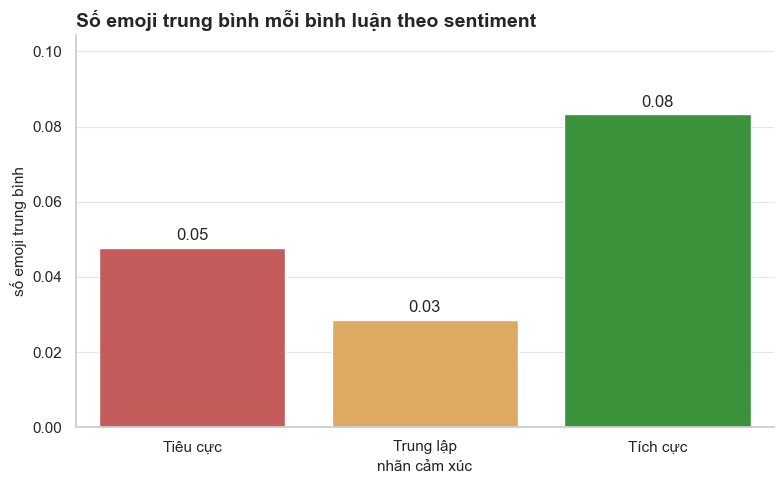

In [123]:
emoji_by_sentiment = (
    df.groupby("sentiment_name")["emoji_count"]
    .mean()
    .reindex(SENTIMENT_ORDER)
    .fillna(0)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))
labels = emoji_by_sentiment["sentiment_name"].tolist()
display_labels = [display_sentiment(label) for label in labels]
values = emoji_by_sentiment["emoji_count"].tolist()
plot_df = emoji_by_sentiment.assign(sentiment_display=display_labels)
sns.barplot(
    data=plot_df,
    x="sentiment_display",
    y="emoji_count",
    hue="sentiment_display",
    hue_order=display_labels,
    ax=ax,
    palette=[SENTIMENT_COLORS[label] for label in labels],
    errorbar=None,
    order=display_labels,
    dodge=False,
    legend=False,
)
style_axes(ax)
ax.set_title("Số emoji trung bình mỗi bình luận theo sentiment", loc="left")
ax.set_xlabel("nhãn cảm xúc")
ax.set_ylabel("số emoji trung bình")
ax.set_ylim(0, max(values) * 1.25 if values else 1)
for container in ax.containers:
    ax.bar_label(container, fmt="{:.2f}", padding=3)
plt.tight_layout()
plt.show()

## Biểu đồ tròn: Phân bố sentiment


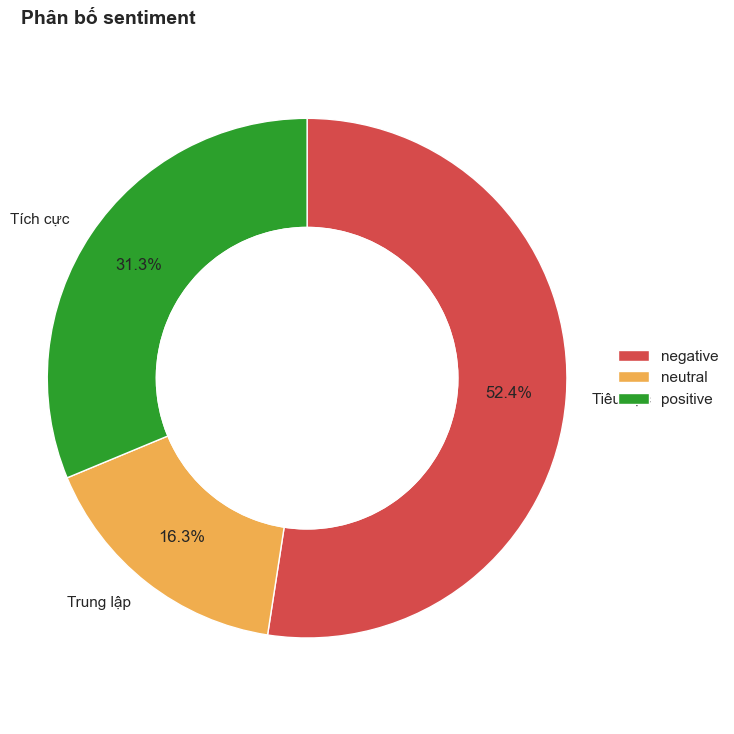

In [124]:
sentiment_counts = (
    df["sentiment_name"]
    .value_counts()
    .reindex(SENTIMENT_ORDER)
    .fillna(0)
    .astype(int)
    .reset_index()
)
sentiment_counts.columns = ["sentiment_name", "count"]

fig, ax = plt.subplots(figsize=(7.5, 7.5))
labels = sentiment_counts["sentiment_name"].tolist()
display_labels = [display_sentiment(label) for label in labels]
values = sentiment_counts["count"].tolist()
colors = [SENTIMENT_COLORS[label] for label in labels]
wedges, texts, autotexts = ax.pie(
    values,
    labels=display_labels,
    colors=colors,
    startangle=90,
    counterclock=False,
    autopct=lambda pct: f"{pct:.1f}%",
    pctdistance=0.78,
    wedgeprops={"width": 0.42, "edgecolor": "white"},
)
ax.add_artist(plt.Circle((0, 0), 0.58, color="white"))
ax.set_title("Phân bố sentiment", loc="left")
ax.axis("equal")
ax.legend(wedges, labels, frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()


Biểu đồ cơ cấu cảm xúc cho thấy một sự phân hóa rõ rệt với tỉ lệ nhãn Tiêu cực chiếm ưu thế (52.4%). Sự mất cân bằng này phản ánh tâm lý người dùng thường để lại phản hồi khi không hài lòng. Đối với việc xây dựng mô hình ABSA, đặc điểm này đòi hỏi các giải pháp xử lý mất cân bằng dữ liệu để đảm bảo mô hình có khả năng nhận diện tốt các đánh giá Tích cực và Trung lập vốn có số lượng mẫu ít hơn

## Histogram: Phân bố số từ

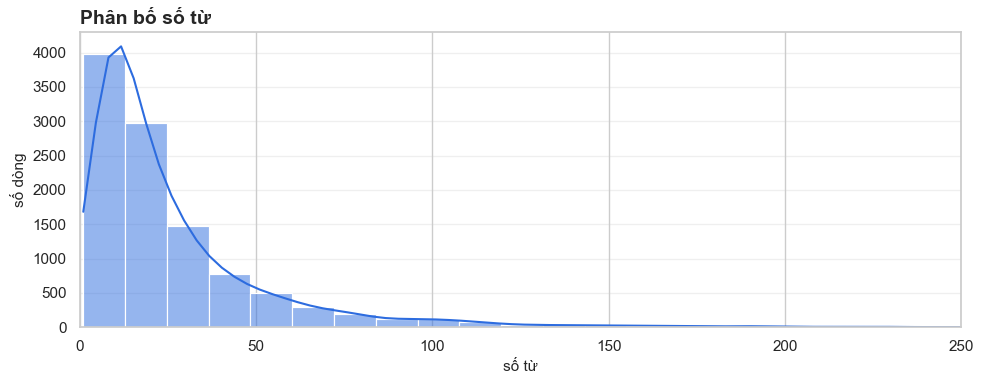

In [139]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(data=df, x="word_count", bins=60, color="#2d6cdf", kde=True, ax=ax, edgecolor="white")
ax.set_xlim(0, 250)
ax.set_title("Phân bố số từ ", loc="left", fontweight='bold')
ax.set_xlabel("số từ")
ax.set_ylabel("số dòng")
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [126]:
explore_df = df[
    [
        ID_COL,
        PRODUCT_COL,
        "content",
        "sentiment_name",
        "word_count",
        "char_count",
        "avg_word_len",
        "lexical_diversity",
        "caps_ratio",
        "emoji_count",
    ]
].copy()

preview_df = explore_df.sample(min(len(explore_df), 5), random_state=42).sort_values([PRODUCT_COL, ID_COL])
display(preview_df)

,review_id,product_name,content,sentiment_name,word_count,char_count,avg_word_len,lexical_diversity,caps_ratio,emoji_count
304,17675364,Mình Chỉ Là Người Bình Thường (Sách Tô Màu),"Cute cực, tô xong iu đời hẳn ý",positive,8,30,2.875000,0.888889,0.032258,0
6750,20126212,Sách - Búp Sen Xanh - Bìa Cứng - Tặng Kèm Obi + Postcard Hành Trình Cứu Nước - Độc Quyền Fahasa,Vì nghe thông tin ngày 10/5 phát hành sẽ chuyển hàng đi ngay nên đã order trước để kịp đi lễ hội làng Sen. Giờ đi về luôn rồi thì hàng m...,negative,59,256,3.355932,0.900000,0.023346,0
3704,5970680,Sách Hiến Pháp Mỹ Được Làm Ra Như Thế Nào,Nội dung hay. Tiếc là bìa sách bị rách một chút.,neutral,11,48,3.454545,0.916667,0.040816,0
3070,19194867,Sách Thần Số Học Ứng Dụng,"Doc de tham khao, thay binh thuong không hap dan",neutral,10,48,3.900000,0.909091,0.020408,0
1597,19621839,Sách Đại Việt Sử Ký Toàn Thư,Chất lượng tốt giao nhanh,positive,5,25,4.200000,0.833333,0.038462,0


## Biểu đồ cột: Độ phủ của các khía cạnh


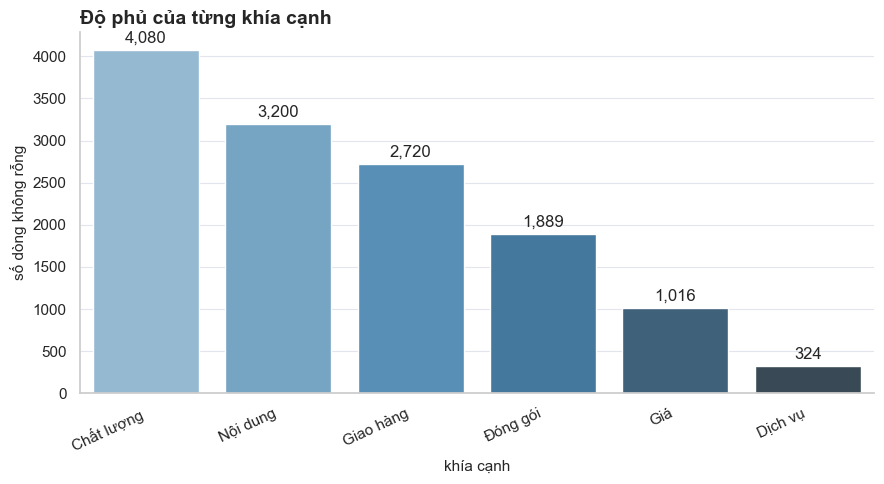

In [127]:
aspect_coverage = (
    df[ASPECT_COLS]
    .notna()
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
aspect_coverage.columns = ["aspect", "count"]
aspect_coverage["aspect_label"] = aspect_coverage["aspect"].map(display_aspect)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=aspect_coverage,
    x="aspect_label",
    y="count",
    hue="aspect_label",
    hue_order=aspect_coverage["aspect_label"].tolist(),
    ax=ax,
    palette=sns.color_palette("Blues_d", n_colors=len(aspect_coverage)),
    errorbar=None,
    order=aspect_coverage["aspect_label"].tolist(),
    dodge=False,
    legend=False,
)
plt.setp(ax.get_xticklabels(), rotation=25, ha="right")
style_axes(ax)
ax.set_title("Độ phủ của từng khía cạnh", loc="left")
ax.set_xlabel("khía cạnh")
ax.set_ylabel("số dòng không rỗng")
for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}", padding=3)
plt.tight_layout()
plt.show()

## Biểu đồ cột chồng: Tỷ lệ sentiment trên 6 khía cạnh


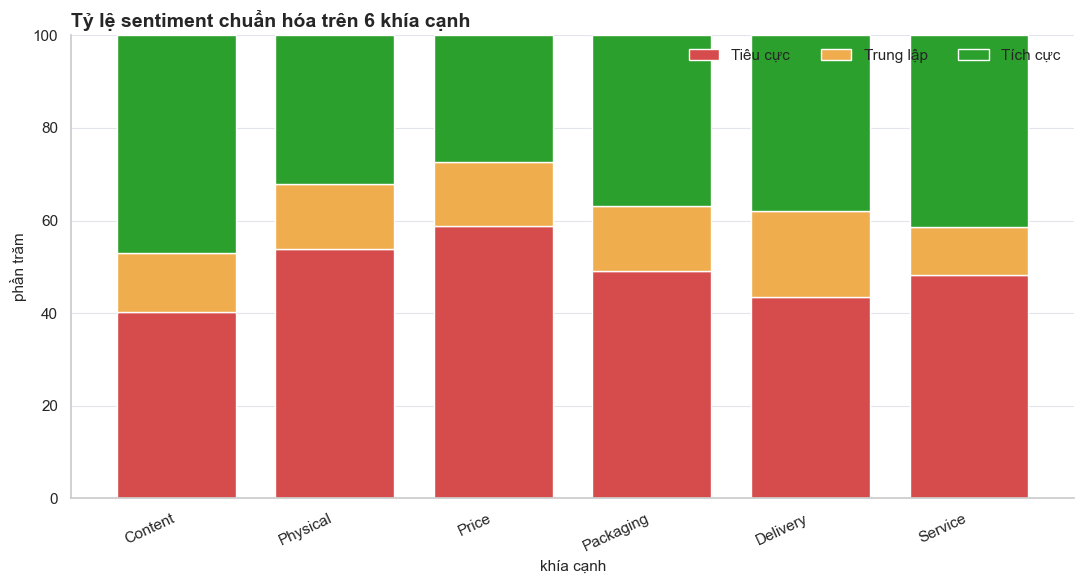

In [128]:
aspect_rows = []
for aspect in ASPECT_COLS:
    subset = df[[aspect, "sentiment_name"]].dropna()
    total = len(subset)
    if total == 0:
        continue
    counts = subset["sentiment_name"].value_counts().reindex(SENTIMENT_ORDER).fillna(0)
    for sentiment in SENTIMENT_ORDER:
        aspect_rows.append(
            {
                "aspect": aspect,
                "sentiment_name": sentiment,
                "percent": float(counts.get(sentiment, 0) * 100 / total),
            }
        )

aspect_pct = pd.DataFrame(aspect_rows)
aspect_pct_pivot = aspect_pct.pivot(index="aspect", columns="sentiment_name", values="percent").reindex(ASPECT_COLS).fillna(0)

fig, ax = plt.subplots(figsize=(11, 6))
labels = [aspect.replace("as_", "").capitalize() for aspect in aspect_pct_pivot.index]
x = np.arange(len(labels))
bottom = np.zeros(len(labels))
for sentiment in SENTIMENT_ORDER:
    values = aspect_pct_pivot[sentiment].to_numpy() if sentiment in aspect_pct_pivot.columns else np.zeros(len(labels))
    ax.bar(x, values, bottom=bottom, color=SENTIMENT_COLORS[sentiment], label=display_sentiment(sentiment), width=0.75)
    bottom += values
ax.set_xticks(x)
ax.set_xticklabels([display_aspect(label) for label in labels], rotation=25, ha="right")
style_axes(ax)
ax.set_ylim(0, 100)
ax.set_title("Tỷ lệ sentiment chuẩn hóa trên 6 khía cạnh", loc="left")
ax.set_xlabel("khía cạnh")
ax.set_ylabel("phần trăm")
ax.legend(frameon=False, ncol=3, loc="upper right")
plt.tight_layout()
plt.show()


## Biểu đồ phân tán: Mức độ chú ý và hài lòng


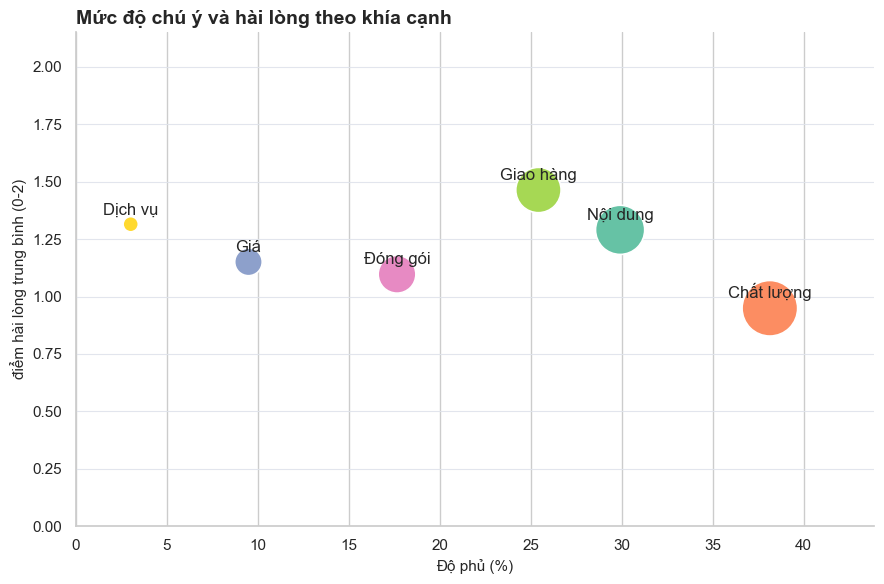

In [129]:
aspect_summary = []
for aspect in ASPECT_COLS:
    subset = df[[aspect]].dropna()
    if subset.empty:
        continue
    aspect_summary.append(
        {
            "aspect": aspect,
            "coverage": int(subset.shape[0]),
            "coverage_pct": float(subset.shape[0] * 100 / len(df)),
            "mean_score": float(subset[aspect].mean()),
        }
    )

aspect_summary = pd.DataFrame(aspect_summary)

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=aspect_summary,
    x="coverage_pct",
    y="mean_score",
    hue="aspect",
    palette="Set2",
    size="coverage",
    sizes=(120, 1600),
    legend=False,
    ax=ax,
    edgecolor="white",
    linewidth=1.2,
)
for _, row in aspect_summary.iterrows():
    ax.text(
        row["coverage_pct"],
        row["mean_score"] + 0.03,
        display_aspect(row["aspect"]),
        ha="center",
        va="bottom",
    )
style_axes(ax)
ax.set_title("Mức độ chú ý và hài lòng theo khía cạnh", loc="left")
ax.set_xlabel("Độ phủ (%)")
ax.set_ylabel("điểm hài lòng trung bình (0-2)")
ax.set_xlim(0, max(aspect_summary["coverage_pct"]) * 1.15 if len(aspect_summary) else 1)
ax.set_ylim(0, 2.15)
plt.tight_layout()
plt.show()

Biểu đồ ma trận khía cạnh chỉ ra một nghịch lý: Khía cạnh quan trọng nhất là 'Chất lượng' lại đang nhận được mức độ hài lòng thấp nhất. Chiến lược cải thiện sản phẩm cần tập trung tối đa vào việc nâng cao chất lượng in ấn/đóng bản sách. Ngược lại, hệ thống có thể tiếp tục phát huy thế mạnh về 'Giao hàng' để duy trì lòng trung thành của khách hàng

## Biểu đồ radar: Sức mạnh của 6 khía cạnh


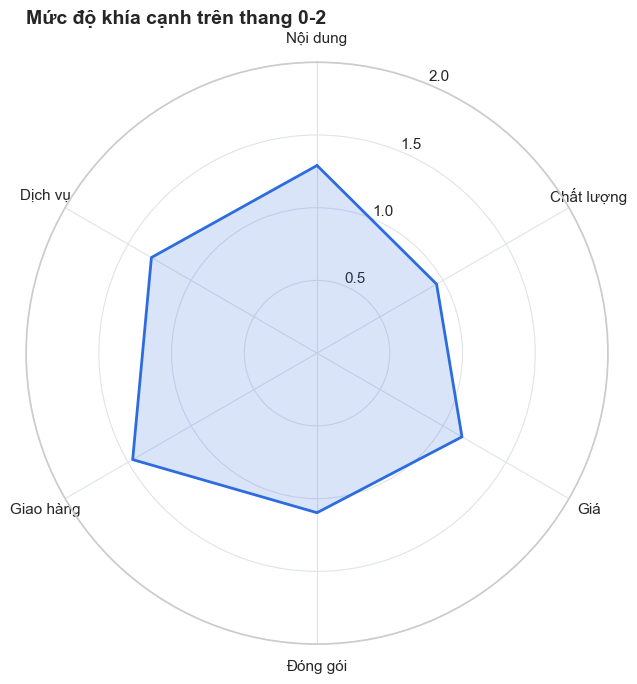

In [130]:
aspect_means = df[ASPECT_COLS].mean().fillna(0)
radar_labels = [display_aspect(aspect) for aspect in ASPECT_COLS]
radar_values = list(aspect_means.values)
radar_values.append(radar_values[0])
angles = np.linspace(0, 2 * np.pi, len(radar_labels), endpoint=False).tolist()
angles.append(angles[0])

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.plot(angles, radar_values, color="#2d6cdf", linewidth=2)
ax.fill(angles, radar_values, color="#2d6cdf", alpha=0.18)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels)
ax.set_yticks([0.5, 1.0, 1.5, 2.0])
ax.set_ylim(0, 2)
ax.grid(color="#dfe3eb", linewidth=0.8)
ax.set_title("Mức độ khía cạnh trên thang 0-2", loc="left")
plt.tight_layout()
plt.show()


Biểu đồ Radar cho thấy một 'vết sẹo' lớn tại khía cạnh Chất lượng. Tổng thể trải nghiệm khách hàng đang được gồng gánh bởi dịch vụ Giao hàng và Nội dung sách. Để biểu đồ này trở nên tròn trịa và đầy đặn hơn (biểu tượng cho sự hài lòng toàn diện), ưu tiên số 1 phải là giải quyết dứt điểm các phàn nàn về Chất lượng và tối ưu hóa thêm về Giá cả

## Bản đồ nhiệt: Ma trận tương quan giữa các khía cạnh


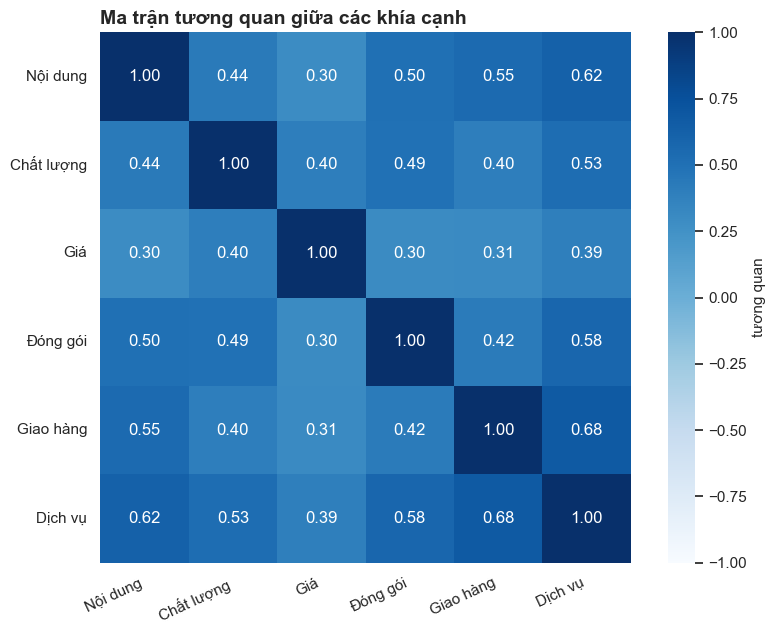

In [131]:
corr = df[ASPECT_COLS].corr()
heatmap_labels = [display_aspect(aspect) for aspect in ASPECT_COLS]

fig, ax = plt.subplots(figsize=(8.5, 6.5))
sns.heatmap(
    corr,
    cmap="Blues",
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    square=True,
    cbar_kws={"label": "tương quan"},
    ax=ax,
)
ax.set_xticklabels(heatmap_labels, rotation=25, ha="right")
ax.set_yticklabels(heatmap_labels, rotation=0)
ax.set_title("Ma trận tương quan giữa các khía cạnh", loc="left")
plt.tight_layout()
plt.show()

Ma trận tương quan chỉ ra rằng trải nghiệm khách hàng trong tập dữ liệu này có tính hệ thống cao. Đặc biệt, khâu 'Dịch vụ' và 'Giao hàng' đóng vai trò là xương sống kết nối toàn bộ sự hài lòng. Ngược lại, khía cạnh 'Giá' cần được phân tích như một yếu tố đứng riêng lẻ, ít bị tác động bởi các yếu tố dịch vụ xung quanh

## Biểu đồ phân tán: Độ đa dạng từ vựng và số từ


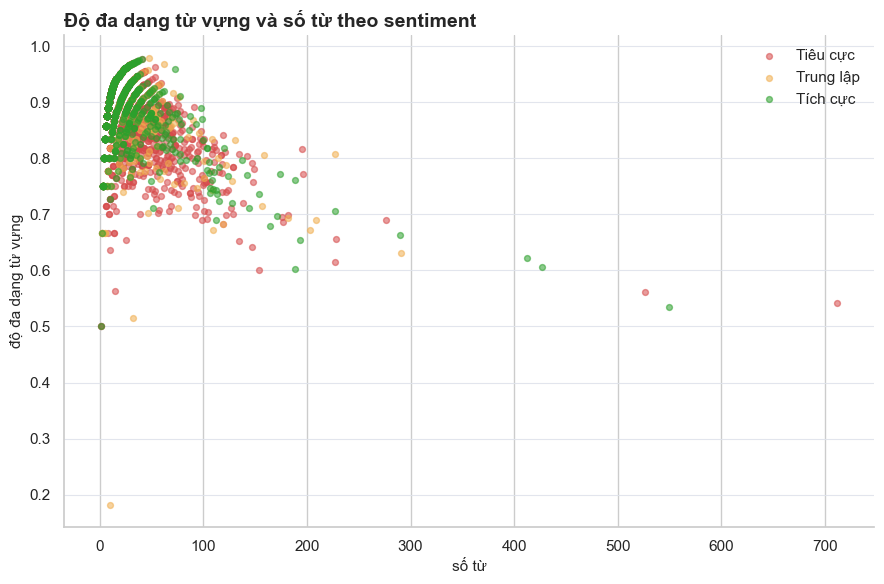

In [132]:
sample = df.sample(min(len(df), 3000), random_state=42)

fig, ax = plt.subplots(figsize=(9, 6))
for label in SENTIMENT_ORDER:
    subset = sample.loc[sample["sentiment_name"] == label]
    ax.scatter(
        subset["word_count"],
        subset["lexical_diversity"],
        s=18,
        alpha=0.55,
        label=display_sentiment(label),
        color=SENTIMENT_COLORS[label],
    )
style_axes(ax)
ax.set_title("Độ đa dạng từ vựng và số từ theo sentiment", loc="left")
ax.set_xlabel("số từ")
ax.set_ylabel("độ đa dạng từ vựng")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


Biểu đồ hành vi ngôn ngữ chỉ ra sự khác biệt tâm lý giữa người khen và người chê: Người viết review tích cực thường cô đọng và giàu vốn từ, trong khi người viết tiêu cực có xu hướng viết dài hơn (kể lể) và lặp lại từ ngữ nhiều hơn. Đối với mô hình AI, các câu review tích cực ngắn có thể mang lại 'tín hiệu' rõ ràng nhất, trong khi các câu tiêu cực dài cần hệ thống chú ý hơn vào ngữ cảnh để không bị nhiễu bởi các từ lặp lại

In [133]:
bigram_frames = {
    label: top_ngrams(
        sentiment_subset(df, label)["content"].map(normalize_text_for_ngrams).tolist(),
        ngram_range=(2, 2),
        top_n=15,
    )
    for label in SENTIMENT_ORDER
}

trigram_frames = {
    label: top_ngrams(
        sentiment_subset(df, label)["content"].map(normalize_text_for_ngrams).tolist(),
        ngram_range=(3, 3),
        top_n=10,
    )
    for label in SENTIMENT_ORDER
}

## Bảng tổng hợp 15 bigram hàng đầu


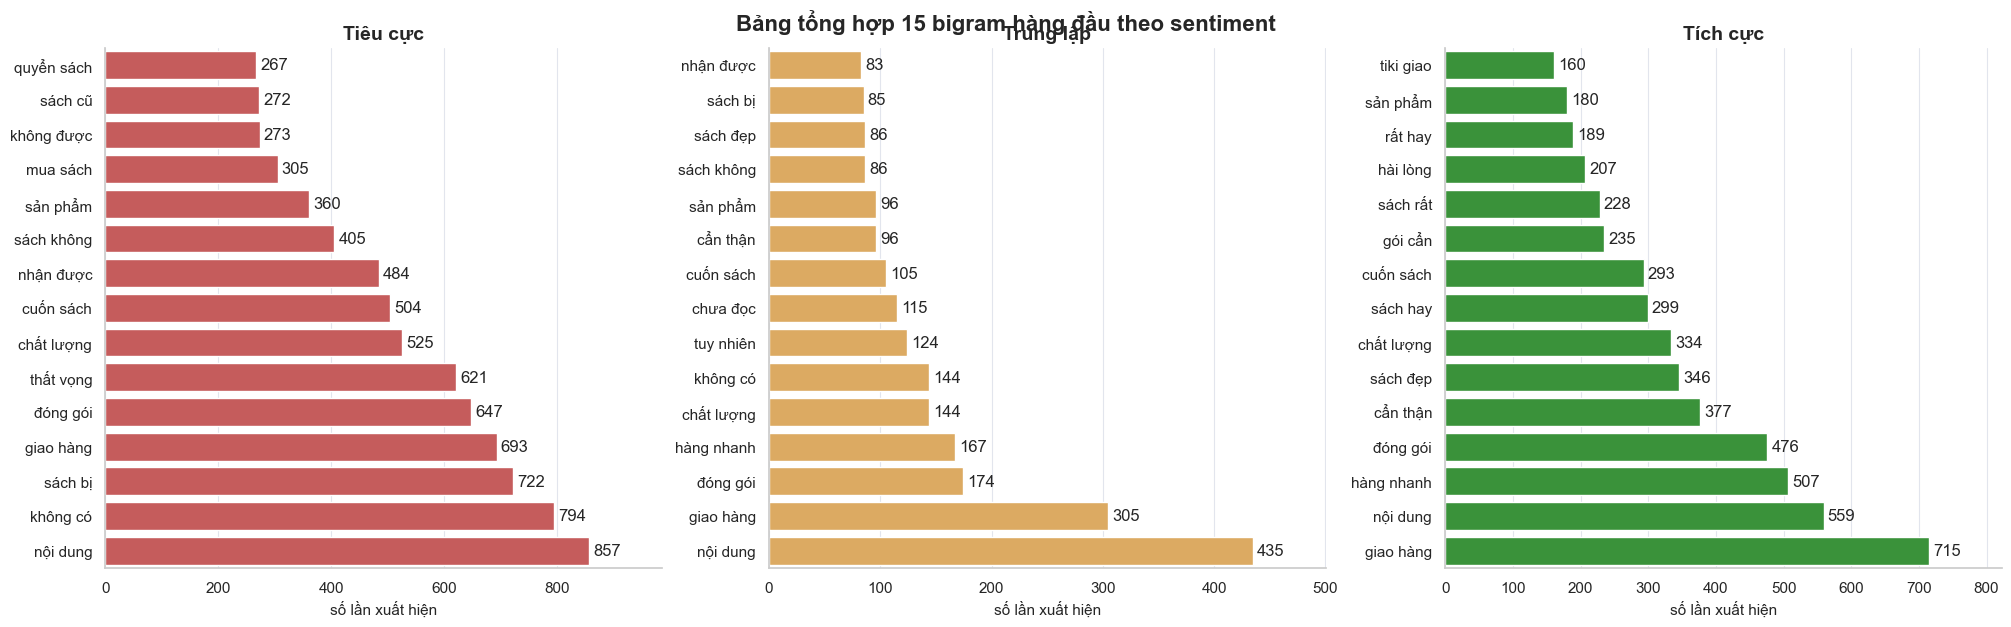

In [134]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)
for ax, label in zip(axes, SENTIMENT_ORDER):
    frame = bigram_frames[label].nlargest(15, "count").sort_values("count")
    sns.barplot(
        data=frame,
        x="count",
        y="ngram",
        ax=ax,
        color=SENTIMENT_COLORS[label],
        errorbar=None,
        orient="h",
        order=frame["ngram"].tolist(),
    )
    style_axes(ax, grid_axis="x")
    ax.set_title(display_sentiment(label))
    ax.set_xlabel("số lần xuất hiện")
    ax.set_ylabel("")
    ax.set_xlim(0, frame["count"].max() * 1.15 if not frame.empty else 1)
    for container in ax.containers:
        ax.bar_label(container, fmt="{:,.0f}", padding=3)
fig.suptitle("Bảng tổng hợp 15 bigram hàng đầu theo sentiment", y=1.02, fontsize=16, fontweight="bold")
plt.show()

## Bảng tổng hợp 10 trigram hàng đầu


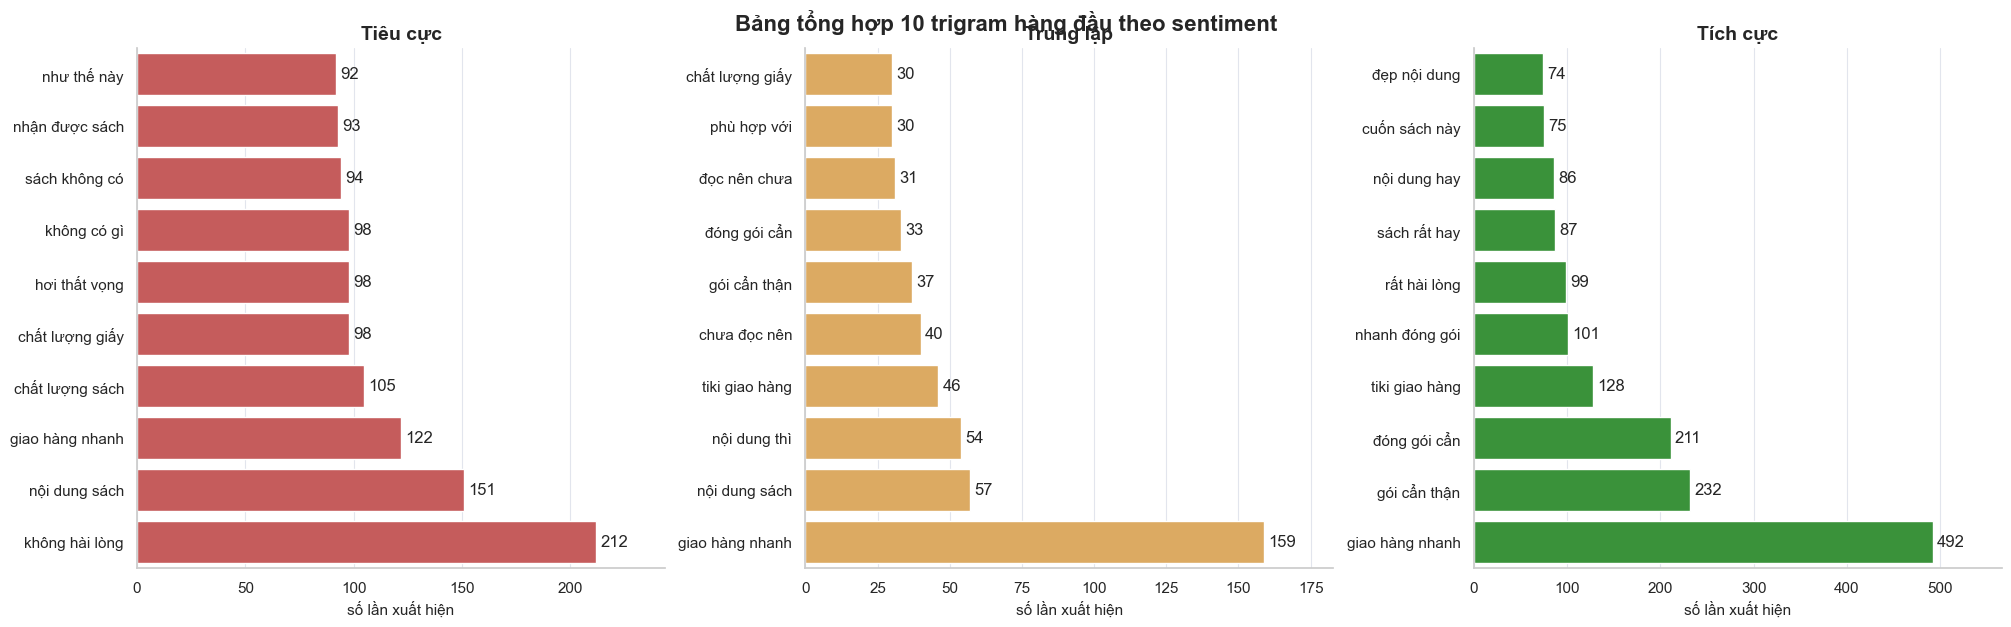

In [135]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)
for ax, label in zip(axes, SENTIMENT_ORDER):
    frame = trigram_frames[label].nlargest(10, "count").sort_values("count")
    sns.barplot(
        data=frame,
        x="count",
        y="ngram",
        ax=ax,
        color=SENTIMENT_COLORS[label],
        errorbar=None,
        orient="h",
        order=frame["ngram"].tolist(),
    )
    style_axes(ax, grid_axis="x")
    ax.set_title(display_sentiment(label))
    ax.set_xlabel("số lần xuất hiện")
    ax.set_ylabel("")
    ax.set_xlim(0, frame["count"].max() * 1.15 if not frame.empty else 1)
    for container in ax.containers:
        ax.bar_label(container, fmt="{:,.0f}", padding=3)
fig.suptitle("Bảng tổng hợp 10 trigram hàng đầu theo sentiment", y=1.02, fontsize=16, fontweight="bold")
plt.show()

## Bảng Word Cloud


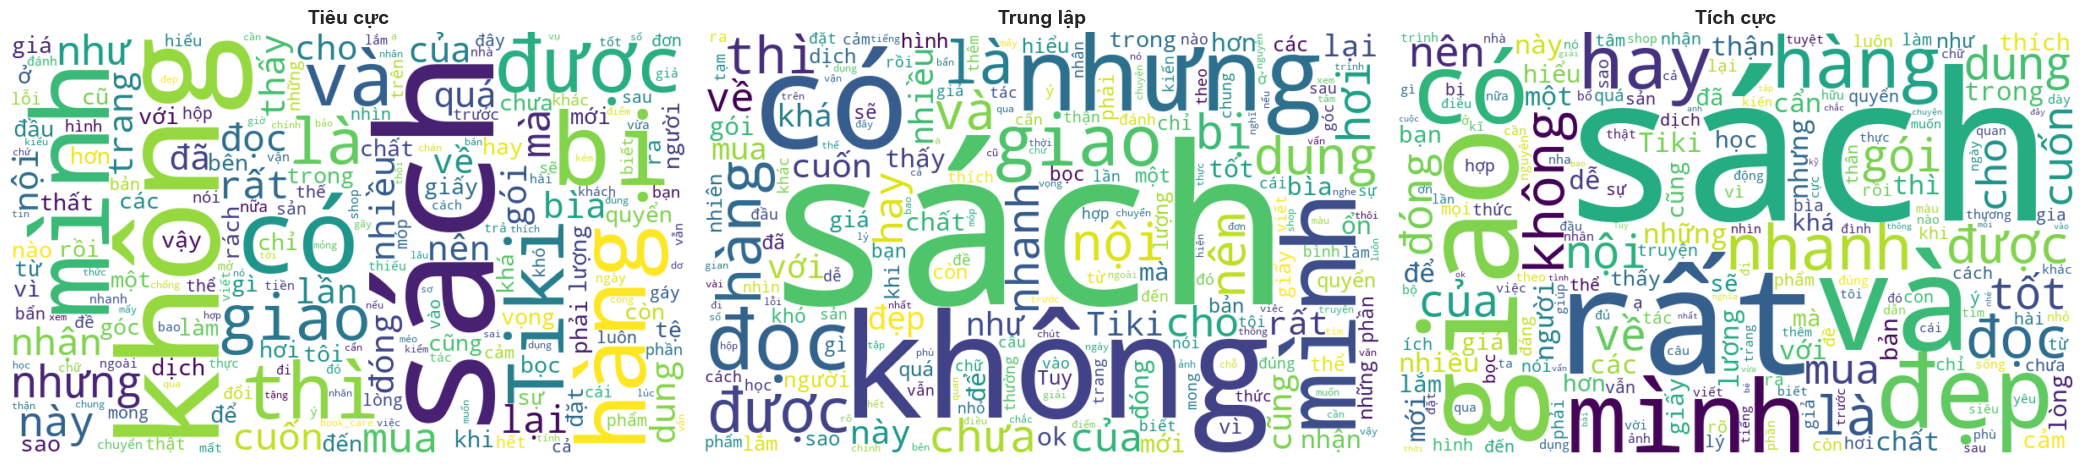

In [136]:
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
for ax, label in zip(axes, SENTIMENT_ORDER):
    text = " ".join(sentiment_subset(df, label)["content"].tolist())
    wc = WordCloud(
        width=800,
        height=500,
        background_color="white",
        collocations=False,
        colormap="viridis",
    ).generate(text if text.strip() else "empty")
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(display_sentiment(label))
    ax.axis("off")
plt.tight_layout()
plt.show()

## Biểu đồ phân tán 3D: TF-IDF + t-SNE


In [137]:
sample_parts = []
for label in SENTIMENT_ORDER:
    subset = df.loc[df["sentiment_name"] == label]
    if subset.empty:
        continue
    sample_parts.append(subset.sample(min(len(subset), 300), random_state=42))

sample_3d = pd.concat(sample_parts, ignore_index=True)
texts_3d = sample_3d["content"].map(normalize_text_for_ngrams).tolist()

tfidf_3d = TfidfVectorizer(max_features=1200, ngram_range=(1, 2), min_df=2)
x_tfidf_3d = tfidf_3d.fit_transform(texts_3d)

n_components_3d = min(50, max(2, x_tfidf_3d.shape[1] - 1))
svd_3d = TruncatedSVD(n_components=n_components_3d, random_state=42)
x_reduced_3d = svd_3d.fit_transform(x_tfidf_3d)

perplexity_3d = min(30, max(5, len(sample_3d) // 10))
tsne_3d = TSNE(
    n_components=3,
    random_state=42,
    perplexity=perplexity_3d,
    init="pca",
    learning_rate="auto",
)
coords_3d = tsne_3d.fit_transform(x_reduced_3d)

plot_df_3d = sample_3d.copy()
plot_df_3d["x"] = coords_3d[:, 0]
plot_df_3d["y"] = coords_3d[:, 1]
plot_df_3d["z"] = coords_3d[:, 2]


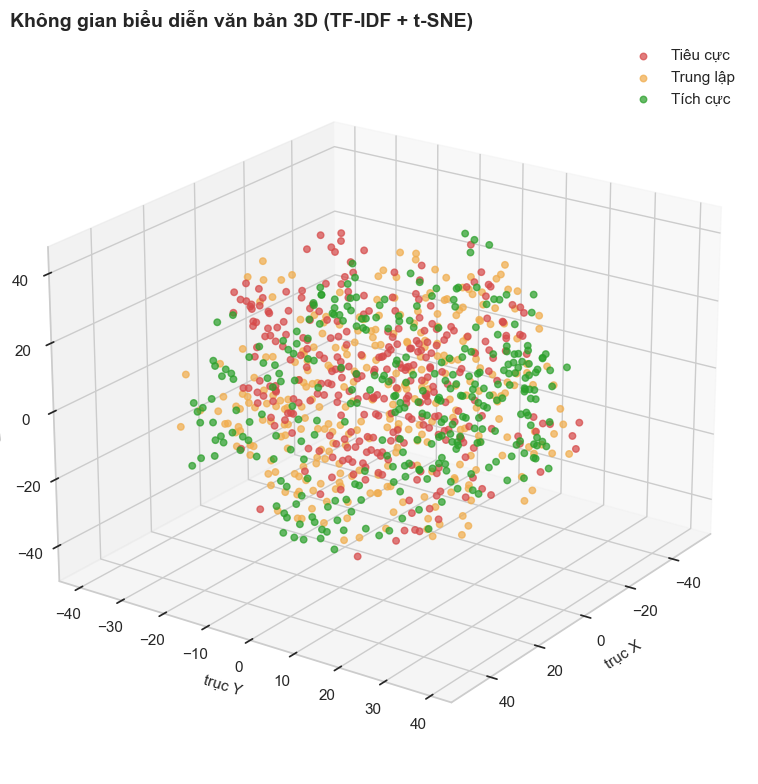

In [138]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
for label in SENTIMENT_ORDER:
    subset = plot_df_3d.loc[plot_df_3d["sentiment_name"] == label]
    ax.scatter(
        subset["x"],
        subset["y"],
        subset["z"],
        s=22,
        alpha=0.72,
        label=display_sentiment(label),
        color=SENTIMENT_COLORS[label],
        depthshade=True,
    )
ax.set_title("Không gian biểu diễn văn bản 3D (TF-IDF + t-SNE)", loc="left")
ax.set_xlabel("trục X")
ax.set_ylabel("trục Y")
ax.set_zlabel("trục Z")
ax.view_init(elev=22, azim=35)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


## Ghi chú

- Dashboard này chỉ dùng cho tập train.
- Số emoji được giữ như một feature bổ trợ cho sentiment.
- N-gram, word cloud và embedding được tính từ `content` đã làm sạch.
- GitHub preview dùng các output Matplotlib tĩnh và ảnh xem trước ở đầu notebook.